# Earthquake Damage Prediction


# About the Project

Earthquakes can cause different levels of structural damage to buildings depending on their construction materials, age, height, foundation type, and geographical location. Predicting building damage severity helps governments, engineers, and disaster management authorities identify vulnerable structures and improve earthquake preparedness. This project applies machine learning techniques to analyse building characteristics and predict earthquake damage severity accurately.


# Domain

Disaster Management and Civil Engineering


# Problem Statement

Building damage caused by earthquakes varies significantly across regions and structures. The objective of this project is to develop a machine learning classification model that predicts the damage grade of buildings affected by an earthquake using structural, geographical, and ownership-related features.

The target variable is **damage_grade**, where:

* **1** represents low damage
* **2** represents moderate damage
* **3** represents severe damage or almost complete destruction


# Objectives

* Perform exploratory data analysis on the earthquake building dataset.
* Understand the factors affecting earthquake damage severity.
* Preprocess the data by handling categorical variables and preparing features for modeling.
* Build multiple machine learning classification models.
* Compare model performance using appropriate classification evaluation metrics.
* Select the best-performing model for earthquake damage prediction.
* Identify the most important factors contributing to severe building damage.
* Provide recommendations to reduce future earthquake-related losses.


# Import Libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

### Observation

The required libraries for data handling, data visualization, preprocessing, machine learning model building, and model evaluation were imported successfully. Warning messages were suppressed to keep the notebook output clean and readable.


# Load the Dataset


In [2]:
train_values = pd.read_csv('data/train_values.csv')
train_labels = pd.read_csv('data/train_labels.csv')

print('Train values shape :', train_values.shape)
print('Train labels shape :', train_labels.shape)

Train values shape : (260601, 39)
Train labels shape : (260601, 2)


### Observation

The feature dataset contains **260,601 records and 39 columns**, while the target dataset contains **260,601 records and 2 columns**. Since both datasets have the same number of records, they can be merged safely using the common identifier **building_id** without any loss of information.


# Merge Features and Target


In [3]:
df = train_values.merge(train_labels, on='building_id')

print('Merged dataset shape :', df.shape)
df.head()

Merged dataset shape : (260601, 40)


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


### Observation

The feature dataset and target dataset were merged successfully using **building_id**. The final dataset contains **260,601 records and 40 columns**, including the target variable **damage_grade**. The sample output confirms that the target column has been added correctly and that no records were lost during the merge operation.


# Dataset Information


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

### Observation

The dataset contains **260,601 records and 40 columns**. Among these, **32 columns are numerical (int64)** and **8 columns are categorical (object)**. All columns contain **260,601 non-null values**, indicating that there are **no missing values** in the dataset. The presence of categorical variables confirms that encoding will be required during preprocessing before machine learning model development.


# Statistical Summary


In [5]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
building_id,260601.0,525675.482773,304544.999032,4.0,261190.0,525757.0,789762.0,1052934.0
geo_level_1_id,260601.0,13.900353,8.033617,0.0,7.0,12.0,21.0,30.0
geo_level_2_id,260601.0,701.074685,412.710734,0.0,350.0,702.0,1050.0,1427.0
geo_level_3_id,260601.0,6257.876148,3646.369645,0.0,3073.0,6270.0,9412.0,12567.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0
has_superstructure_adobe_mud,260601.0,0.088645,0.284231,0.0,0.0,0.0,0.0,1.0
has_superstructure_mud_mortar_stone,260601.0,0.761935,0.425900,0.0,1.0,1.0,1.0,1.0


### Observation

The statistical summary shows that most buildings have **2 floors** (median = 2), indicating that low-rise structures dominate the dataset. The median building age is **15 years**, while the maximum age is **995 years**, suggesting the presence of extreme values that require further investigation. The median **area_percentage** is **7** and the median **height_percentage** is **5**, indicating that most buildings are relatively small in area and height. Additionally, the feature **has_superstructure_mud_mortar_stone** has a mean value of approximately **0.76**, which means that nearly **76% of buildings** contain mud-mortar-stone superstructures.


# Missing Value Analysis


In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

### Observation

The missing value analysis returned an empty series, which indicates that **no missing values are present in any column of the dataset**. Since all features contain complete information, no missing value treatment or imputation was required before further analysis and model building.


# Duplicate Check


In [7]:
duplicate_count = df.duplicated().sum()

print('Duplicate rows :', duplicate_count)

Duplicate rows : 0


### Observation

The dataset contains **0 duplicate rows**, which indicates that each building record is unique. Since no duplicate observations were found, no duplicate removal was required before further analysis and model building.


## Exploratory Data Analysis (EDA)






### Distribution of Damage Grade

damage_grade
1     25124
2    148259
3     87218
Name: count, dtype: int64


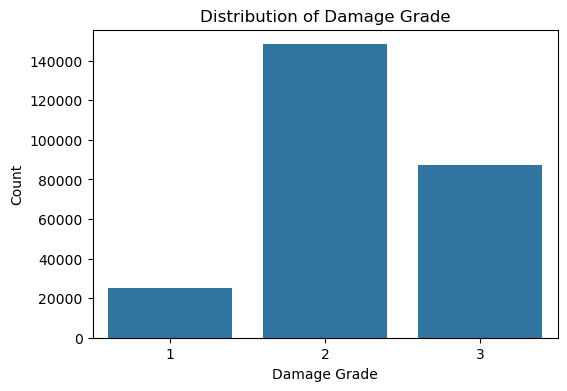

In [8]:
damage_counts = df['damage_grade'].value_counts().sort_index()

print(damage_counts)

plt.figure(figsize=(6,4))

sns.countplot(x='damage_grade', data=df)

plt.title('Distribution of Damage Grade')
plt.xlabel('Damage Grade')
plt.ylabel('Count')

plt.show()

### Observation

The target variable **damage_grade** contains three classes: **1, 2, and 3**. The distribution is imbalanced, with **damage grade 2 containing 148,259 records (56.89%)**, which is the majority class. **Damage grade 3 contains 87,218 records (33.47%)**, while **damage grade 1 contains only 25,124 records (9.64%)**. This imbalance indicates that machine learning models may become biased toward the majority class, and techniques such as **SMOTE** may be required during preprocessing to improve class balance.




### Distribution of Building Age


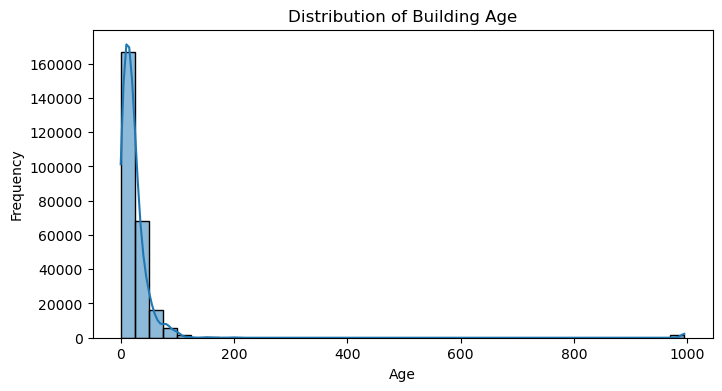

In [9]:
plt.figure(figsize=(8,4))

sns.histplot(df['age'], bins=40, kde=True)

plt.title('Distribution of Building Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### Observation

The distribution of **building age** is highly **right-skewed**. Most buildings are concentrated in the lower age range, particularly below **50 years**, while the frequency decreases sharply as age increases. A small number of buildings have extremely high age values approaching **1000 years**, indicating the presence of significant outliers. These extreme values may represent very old structures and should be examined carefully during outlier analysis.



### Distribution of Number of Floors Before Earthquake


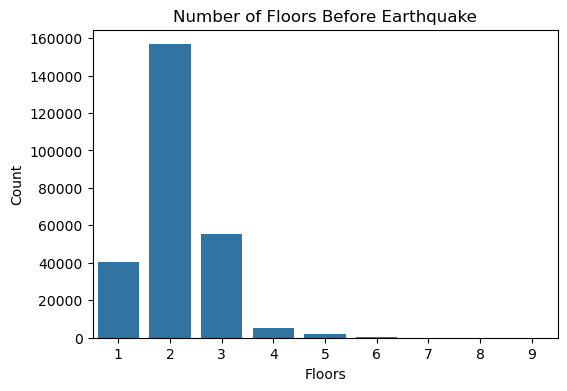

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='count_floors_pre_eq', data=df)

plt.title('Number of Floors Before Earthquake')
plt.xlabel('Floors')
plt.ylabel('Count')

plt.show()



### Observation

The distribution of **count_floors_pre_eq** shows that buildings with **2 floors** are the most common in the dataset, followed by **3-floor** and **1-floor** buildings. Buildings with **4 or more floors** are comparatively rare, and very few buildings have more than **6 floors**. This indicates that the dataset is dominated by low-rise structures, which is consistent with the statistical summary where the median number of floors is **2**.


### Area Percentage vs Damage Grade


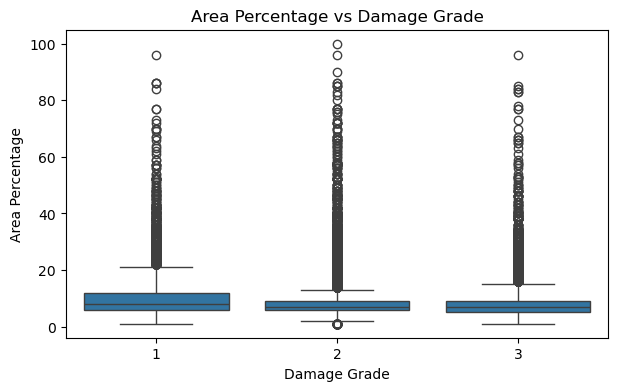

In [11]:
plt.figure(figsize=(7,4))

sns.boxplot(x='damage_grade', y='area_percentage', data=df)

plt.title('Area Percentage vs Damage Grade')
plt.xlabel('Damage Grade')
plt.ylabel('Area Percentage')

plt.show()



### Observation

The boxplot shows that the median **area_percentage** is relatively similar across damage grades **1, 2, and 3**, with most values concentrated between approximately **5 and 10**. However, a large number of observations lie above the upper whisker in all three classes, indicating the presence of many high-area buildings. The similarity of the medians suggests that **area_percentage alone may not strongly differentiate damage grades**, although extreme area values are present in every category.



### Height Percentage vs Damage Grade


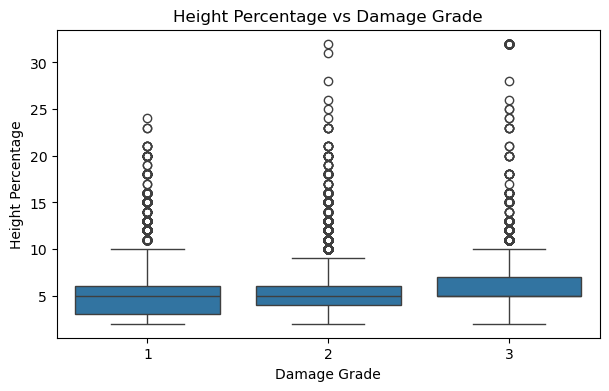

In [12]:
plt.figure(figsize=(7,4))

sns.boxplot(x='damage_grade', y='height_percentage', data=df)

plt.title('Height Percentage vs Damage Grade')
plt.xlabel('Damage Grade')
plt.ylabel('Height Percentage')

plt.show()



### Observation

The boxplot indicates that buildings with **damage grade 3** tend to have a **higher median height_percentage** compared with damage grades 1 and 2. The spread of height values is also larger for damage grade 3, and several high-height outliers are present. This suggests that taller buildings may be more susceptible to severe earthquake damage, making **height_percentage** a potentially important predictive feature.


### Distribution of Foundation Type


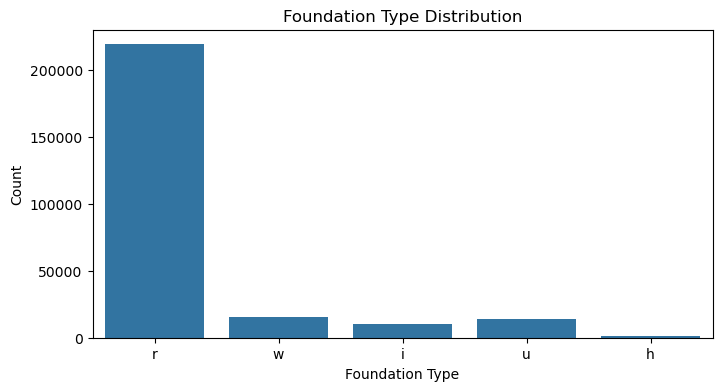

In [13]:
plt.figure(figsize=(8,4))

sns.countplot(x='foundation_type', data=df)

plt.title('Foundation Type Distribution')
plt.xlabel('Foundation Type')
plt.ylabel('Count')

plt.show()

### Observation

The output shows that **foundation type `r`** has the highest count, contributing the majority of buildings in the dataset. Foundation type `w` appears as the second most common category, while categories such as `u`, `i`, and `h` occur in much smaller numbers. This indicates that most buildings were constructed using foundation type `r`, and the feature is highly imbalanced across categories.


### Distribution of Roof Type


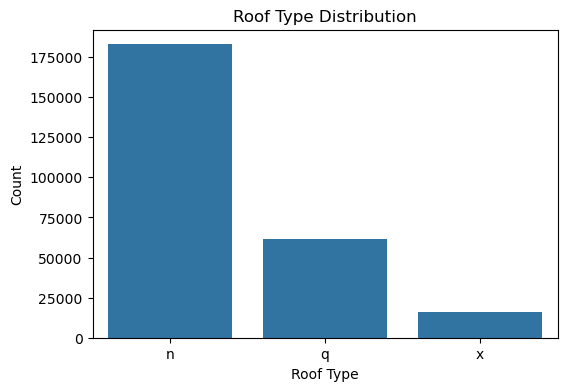

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='roof_type', data=df)

plt.title('Roof Type Distribution')
plt.xlabel('Roof Type')
plt.ylabel('Count')

plt.show()

### Observation

The plot clearly shows that **roof type `n`** is overwhelmingly dominant in the dataset, with a substantially larger count than roof types `q` and `x`. Roof type `q` forms the second-largest group, while roof type `x` is comparatively rare. The distribution suggests that a single roof construction type is used in most buildings.


### Distribution of Land Surface Condition


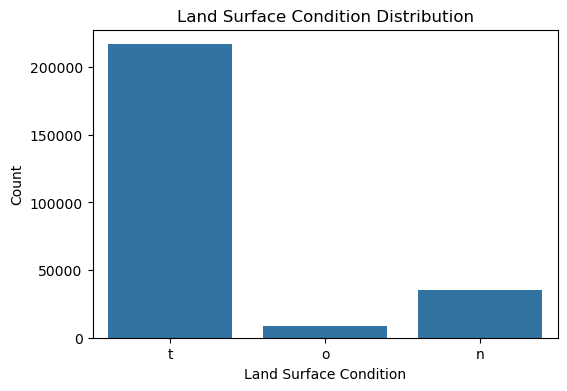

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='land_surface_condition', data=df)

plt.title('Land Surface Condition Distribution')
plt.xlabel('Land Surface Condition')
plt.ylabel('Count')

plt.show()

### Observation

The output indicates that **land surface condition `t`** has the highest frequency in the dataset. Category `n` is less common, and category `o` has the smallest count. This means that most buildings are located on land surface condition `t`, making it the dominant terrain condition in the dataset.


### Correlation Heatmap


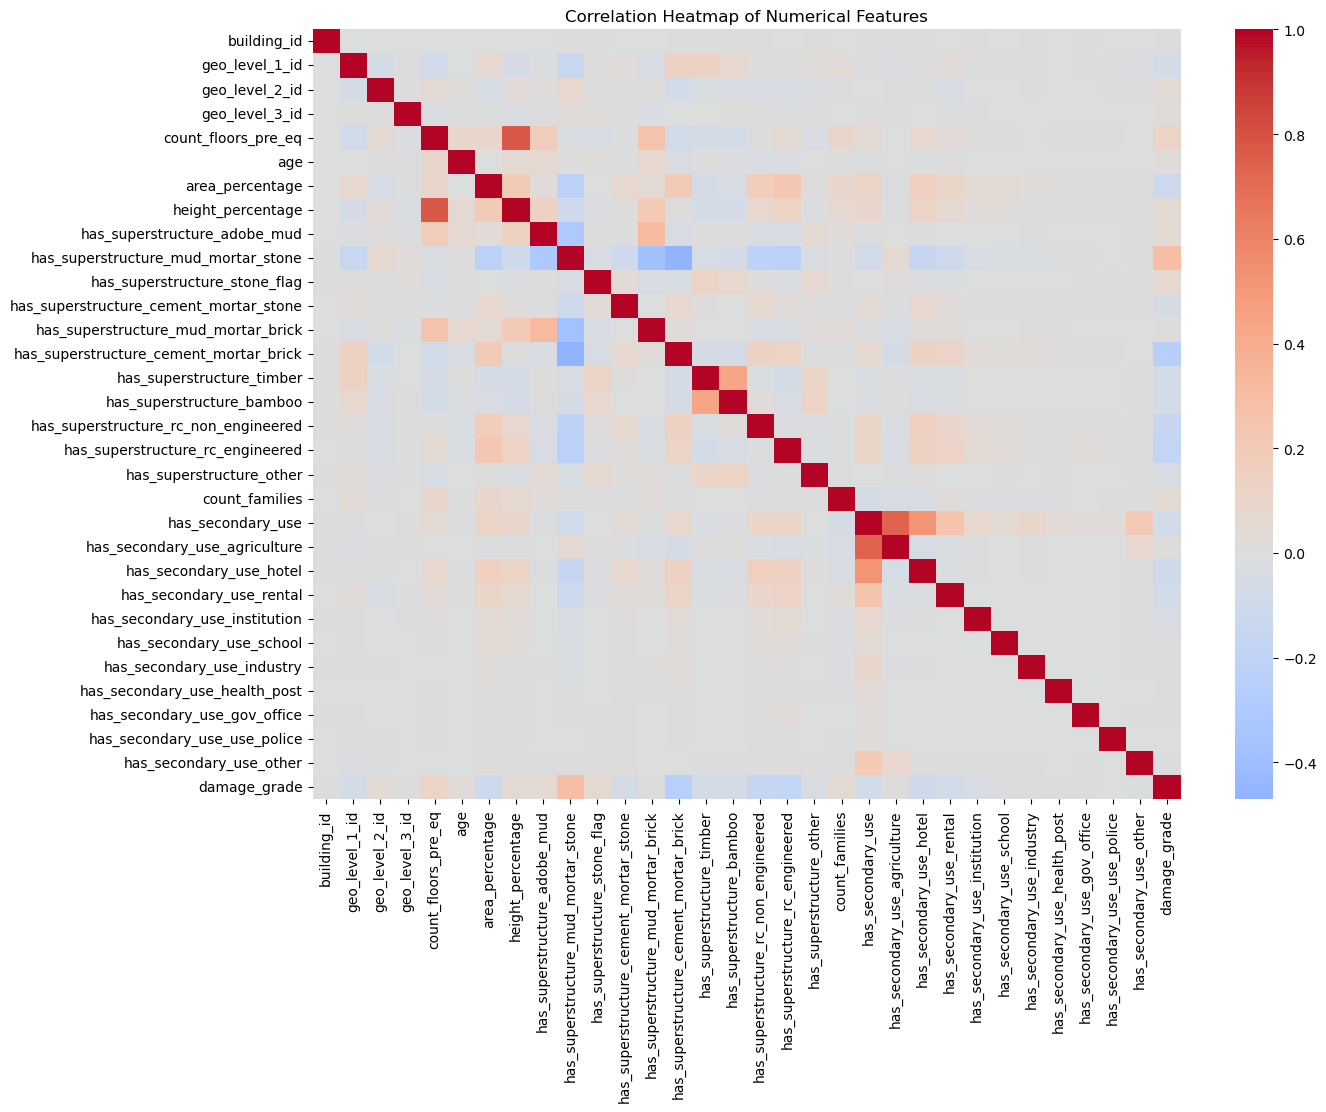

In [16]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(numeric_cols.corr(), cmap='coolwarm', center=0)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

### Observation

The heatmap shows that most numerical features have **weak correlations**, as indicated by the light colors across the matrix. No feature pair exhibits a very strong positive or negative correlation close to **+1 or -1**, which suggests that severe multicollinearity is not present. A relatively stronger positive relationship is visible between **count_floors_pre_eq** and **height_percentage**, which is expected because buildings with more floors generally have greater height.



## EDA Summary

The exploratory data analysis revealed the following key findings:

* The target variable **damage_grade** is imbalanced, with **damage grade 2 containing 148,259 records (56.89%)**, making it the majority class.
* Most buildings are relatively young, with a large concentration below **50 years**, while a small number of buildings have extremely high ages approaching **1000 years**.
* Buildings with **2 floors** are the most common, indicating that low-rise structures dominate the dataset.
* **Area percentage** shows substantial overlap across all damage grades, suggesting limited discriminatory power when considered alone.
* **Height percentage** is visibly higher for many buildings in damage grade 3, indicating a stronger relationship with severe damage.
* **Foundation type `r`**, **roof type `n`**, and **land surface condition `t`** are the dominant categories in their respective features.
* The correlation heatmap shows generally weak correlations among numerical variables, with no evidence of severe multicollinearity.

Overall, the EDA suggests that earthquake damage severity is influenced by a combination of structural characteristics, building height, construction type, and geographical conditions rather than by a single feature.



## Issues Identified During EDA and Their Solutions

During exploratory data analysis, several data-related issues were identified. Each issue was carefully examined, and an appropriate treatment strategy was selected before model development.

### 1. Imbalanced Target Variable

**Issue Identified**

The target variable **damage_grade** is imbalanced:

* Grade 1: 25,124 records (9.64%)
* Grade 2: 148,259 records (56.89%)
* Grade 3: 87,218 records (33.47%)

The majority class is damage grade 2.

**Potential Impact**

Machine learning models may become biased toward the majority class, resulting in poor recall for minority classes.

**Solution**

Apply **SMOTE (Synthetic Minority Over-sampling Technique)** only on the training dataset after train-test split.

**Implementation**

* Split the data into training and testing sets.
* Apply SMOTE on `X_train` and `y_train`.
* Keep the test dataset unchanged for unbiased evaluation.

---

### 2. Extreme Outliers in Building Age

**Issue Identified**

The age distribution is highly right-skewed, and some buildings have ages close to **995 years**.

**Potential Impact**

Extreme values can distort statistical measures such as the mean and may affect models that are sensitive to outliers.

**Solution**

* Perform IQR-based outlier analysis.
* Retain the values if they represent genuine buildings.
* Consider percentile capping (for example, 99th percentile) only if model performance is adversely affected.

**Reason for Retention**

The dataset represents real buildings, and very old structures may genuinely exist.

---

### 3. Outliers in Area Percentage

**Issue Identified**

The boxplot of **area_percentage** shows many observations above the upper whisker across all damage grades.

**Potential Impact**

Large-area buildings may appear as statistical outliers.

**Solution**

Retain the observations because they are likely to represent genuine large buildings rather than data-entry errors.

**Reason for Retention**

Tree-based models such as Random Forest and Gradient Boosting are relatively robust to outliers.

---

### 4. Outliers in Height Percentage

**Issue Identified**

Several high values are present in **height_percentage**, especially for damage grade 3.

**Potential Impact**

Extreme height values may influence some algorithms.

**Solution**

Retain the values because they show a meaningful relationship with severe damage and may carry predictive information.

---

### 5. Highly Skewed Numerical Distribution

**Issue Identified**

The **age** feature is strongly right-skewed.

**Potential Impact**

Skewed distributions can affect models that assume approximately symmetric feature distributions.

**Solution**

If required, apply transformations such as `log1p(age)` or use robust scaling. Since the final selected models are tree-based, transformation is optional.

---

### 6. Imbalanced Categorical Features

**Issue Identified**

Foundation type `r`, roof type `n`, and land surface condition `t` dominate their respective categories.

**Potential Impact**

Rare categories may contribute less information during model training.

**Solution**

Encode the categories properly using Label Encoding or One-Hot Encoding. Rare-category grouping is optional because the dataset is large.

---

### 7. Presence of Identifier Column

**Issue Identified**

`building_id` is a unique identifier.

**Potential Impact**

It provides no predictive information and may introduce noise.

**Solution**

Remove `building_id` before model training.

---

### 8. Mixed Data Types

**Issue Identified**

The dataset contains both numerical and categorical variables.

**Potential Impact**

Machine learning algorithms require numerical input.

**Solution**

Encode all categorical columns before model development.

---

### 9. No Missing Values

**Issue Identified**

No missing values were found.

**Potential Impact**

No issue.

**Solution**

No imputation was required.

---



## Data Preprocessing

Data preprocessing is performed to prepare the dataset for machine learning algorithms. In this stage, unnecessary columns are removed, categorical variables are encoded, the data is split into training and testing sets, and class imbalance is handled using SMOTE.


### Remove Identifier Column


In [17]:
df.drop('building_id', axis=1, inplace=True)

print('building_id column removed successfully')

building_id column removed successfully


### Observation

The **building_id** column was removed from the dataset because it is a unique identifier and does not contribute to earthquake damage prediction. Removing identifier columns prevents the model from learning meaningless patterns.


### Identify Categorical Columns


In [18]:
categorical_columns = df.select_dtypes(include='object').columns

print('Categorical columns:')
print(categorical_columns)
print('\nNumber of categorical columns :', len(categorical_columns))

Categorical columns:
Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='object')

Number of categorical columns : 8


### Observation

The dataset contains **8 categorical columns**:

* `land_surface_condition`
* `foundation_type`
* `roof_type`
* `ground_floor_type`
* `other_floor_type`
* `position`
* `plan_configuration`
* `legal_ownership_status`

These columns contain text-based categories and cannot be used directly by machine learning algorithms. Therefore, all categorical features must be converted into numerical form during preprocessing.



### Encode Categorical Variables


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print('Categorical variables encoded successfully')

df[categorical_columns].head()

Categorical variables encoded successfully


,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,legal_ownership_status
0,2,2,0,0,1,3,2,2
1,1,2,0,3,1,2,2,2
2,2,2,0,0,3,3,2,2
3,2,2,0,0,3,2,2,2
4,2,2,0,0,3,2,2,2


### Observation

All **8 categorical variables** were successfully converted into numerical values using **Label Encoding**. The output confirms that the original text categories have been replaced with integer labels, allowing machine learning algorithms to process these features during model training. The dataset now contains only numerical values.


### Define Features and Target Variable


In [20]:
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']

print('Feature matrix shape :', X.shape)
print('Target vector shape  :', y.shape)

Feature matrix shape : (260601, 38)
Target vector shape  : (260601,)


### Observation

The dataset was successfully divided into **features (X)** and the **target variable (y)**. The feature matrix contains **260,601 records and 38 predictor variables**, while the target vector contains **260,601 damage-grade labels**. This confirms that the target column was separated correctly and that the number of samples remains consistent in both X and y.


### Train-Test Split


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train shape :', X_train.shape)
print('X_test shape  :', X_test.shape)
print('y_train shape :', y_train.shape)
print('y_test shape  :', y_test.shape)

X_train shape : (208480, 38)
X_test shape  : (52121, 38)
y_train shape : (208480,)
y_test shape  : (52121,)


### Observation

The dataset was successfully divided into training and testing sets using an **80:20 ratio**. The training set contains **208,480 records and 38 features**, while the testing set contains **52,121 records and 38 features**. The target vectors contain **208,480** and **52,121** records respectively, confirming that the split was performed correctly. Stratified sampling was used, so the original distribution of damage grades is preserved in both training and testing datasets, ensuring fair model evaluation.


## Handle Class Imbalance Using SMOTE

The target variable is imbalanced, with damage grade 2 having substantially more records than damage grades 1 and 3. To reduce model bias toward the majority class, SMOTE (Synthetic Minority Over-sampling Technique) will be applied to the training dataset only.


In [22]:
from imblearn.over_sampling import SMOTE

### Observation

The **SMOTE** library was imported successfully. This technique will be used to balance the class distribution in the training dataset before model training.


## Class Distribution Before SMOTE


In [23]:
print(y_train.value_counts())

damage_grade
2    118607
3     69774
1     20099
Name: count, dtype: int64


### Observation

The training dataset is clearly **imbalanced**. **Damage grade 2** contains **118,607 records**, while **damage grade 3** contains **69,774 records** and **damage grade 1** contains only **20,099 records**. The majority class is damage grade 2, which has almost six times more samples than damage grade 1. This imbalance may cause machine learning models to favor the majority class during training, leading to poor recall for minority classes. Therefore, SMOTE will be applied to balance the training dataset before model development.


## Apply SMOTE


In [24]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Shape before SMOTE :', X_train.shape)
print('Shape after SMOTE  :', X_train_smote.shape)

Shape before SMOTE : (208480, 38)
Shape after SMOTE  : (355821, 38)


### Observation

SMOTE was applied successfully to the training dataset. Before applying SMOTE, the training feature matrix contained **208,480 records and 38 features**. After applying SMOTE, the number of training records increased to **355,821**, while the number of features remained **38**. The increase in sample size occurred because synthetic samples were generated for the minority classes, which helps reduce class imbalance and improve model learning for underrepresented damage grades.


## Class Distribution After SMOTE


In [25]:
print(y_train_smote.value_counts())

damage_grade
3    118607
2    118607
1    118607
Name: count, dtype: int64


### Observation

After applying SMOTE, all three damage-grade classes contain exactly **118,607 records each**. This confirms that the training dataset has been successfully balanced. The balanced distribution helps machine learning models learn each class more effectively and reduces bias toward the majority class. The test dataset remains unchanged, ensuring unbiased model evaluation.


# Model Building

Multiple classification models will be developed and evaluated to predict earthquake damage grades. The models will be trained using the SMOTE-balanced training dataset and evaluated on the original test dataset.


## Logistic Regression

Logistic Regression is used as a baseline classification model. It estimates the probability of each damage grade and predicts the class with the highest probability.


In [26]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test)

## Logistic Regression Evaluation


In [27]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print('Accuracy :', lr_accuracy)
print('Weighted F1 Score :', lr_f1)

print('\nClassification Report:\n')
print(classification_report(y_test, lr_pred))

Accuracy : 0.42102031810594576
Weighted F1 Score : 0.41679092853456357

Classification Report:

              precision    recall  f1-score   support

           1       0.23      0.57      0.33      5025
           2       0.63      0.28      0.39     29652
           3       0.41      0.62      0.49     17444

    accuracy                           0.42     52121
   macro avg       0.42      0.49      0.40     52121
weighted avg       0.52      0.42      0.42     52121



### Observation

The Logistic Regression model achieved an **accuracy of 42.10%** and a **weighted F1-score of 41.68%** on the test dataset. The model shows moderate recall for damage grades **1 (0.57)** and **3 (0.62)**, but the recall for the majority class **2** is relatively low at **0.28**. This indicates that after applying SMOTE, the model became more capable of identifying minority classes, especially damage grades 1 and 3, but overall classification performance remains limited.

The precision values are also relatively low, particularly for damage grade 1, which suggests a considerable number of false-positive predictions. Since Logistic Regression is a linear model, it may not be able to capture the complex non-linear relationships between building characteristics and earthquake damage severity.

Overall, Logistic Regression serves as a **baseline model**, and more advanced non-linear models such as Decision Tree and Random Forest are expected to provide better predictive performance on this dataset.


## Decision Tree Classifier

Decision Tree is a non-linear classification algorithm that splits the data based on feature values and can capture complex relationships between building characteristics and damage grades.


In [28]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_smote, y_train_smote)

dt_pred = dt_model.predict(X_test)

## Decision Tree Evaluation


In [29]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average='weighted')

print('Accuracy :', dt_accuracy)
print('Weighted F1 Score :', dt_f1)

print('\nClassification Report:\n')
print(classification_report(y_test, dt_pred))

Accuracy : 0.646764260087105
Weighted F1 Score : 0.6495353091815185

Classification Report:

              precision    recall  f1-score   support

           1       0.44      0.55      0.49      5025
           2       0.72      0.67      0.69     29652
           3       0.61      0.63      0.62     17444

    accuracy                           0.65     52121
   macro avg       0.59      0.62      0.60     52121
weighted avg       0.65      0.65      0.65     52121



### Observation

The Decision Tree model achieved an **accuracy of 64.68%** and a **weighted F1-score of 64.95%**, which is a substantial improvement over Logistic Regression. The model performs reasonably well across all three damage grades.

* **Damage Grade 1:** Precision = 0.44, Recall = 0.55, F1-score = 0.49
* **Damage Grade 2:** Precision = 0.72, Recall = 0.67, F1-score = 0.69
* **Damage Grade 3:** Precision = 0.61, Recall = 0.63, F1-score = 0.62

The model shows balanced performance across classes, with particularly strong results for damage grade 2. Compared with Logistic Regression, the Decision Tree captures non-linear relationships more effectively, leading to higher accuracy and F1-score. The weighted F1-score of **64.95%** indicates that the model provides a considerably better balance between precision and recall across all damage categories.

Overall, the Decision Tree model demonstrates that earthquake damage prediction benefits from non-linear decision boundaries and feature interactions.


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive accuracy and reduce overfitting. It is particularly effective for structured tabular datasets with complex feature interactions.


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)

## Random Forest Evaluation


In [31]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print('Accuracy :', rf_accuracy)
print('Weighted F1 Score :', rf_f1)

print('\nClassification Report:\n')
print(classification_report(y_test, rf_pred))

Accuracy : 0.7053970568484872
Weighted F1 Score : 0.7058304769582554

Classification Report:

              precision    recall  f1-score   support

           1       0.55      0.61      0.58      5025
           2       0.75      0.75      0.75     29652
           3       0.69      0.66      0.67     17444

    accuracy                           0.71     52121
   macro avg       0.66      0.67      0.67     52121
weighted avg       0.71      0.71      0.71     52121



### Observation

The Random Forest model achieved an **accuracy of 70.54%** and a **weighted F1-score of 70.58%**, which is the best performance obtained so far. The model performs consistently across all three damage grades and shows a good balance between precision and recall.

* **Damage Grade 1:** Precision = 0.55, Recall = 0.61, F1-score = 0.58
* **Damage Grade 2:** Precision = 0.75, Recall = 0.75, F1-score = 0.75
* **Damage Grade 3:** Precision = 0.69, Recall = 0.66, F1-score = 0.67

The model achieves the highest recall for damage grade 2 and maintains substantially better performance for grades 1 and 3 compared with the previous models. The weighted F1-score above **70%** indicates that the model generalizes well across the imbalanced damage categories.

Compared with Logistic Regression and Decision Tree, Random Forest benefits from ensemble learning, where multiple decision trees collectively reduce overfitting and improve predictive stability. The improvement demonstrates that ensemble methods are highly effective for earthquake damage prediction using structural and geographical features.

At this stage, **Random Forest is the best-performing model and is selected as the final candidate model for further tuning and evaluation**.


##  XGBoost (Extreme Gradient Boosting) 

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds decision trees sequentially, where each new tree focuses on correcting the errors made by the previous trees. It is widely used in structured tabular datasets because it can model complex non-linear relationships, handle feature interactions effectively, and often achieves higher predictive performance than individual decision trees and standard random forests.


In [32]:
from xgboost import XGBClassifier

### Observation

The XGBoost library was imported successfully and is ready for model development.


## Prepare Target Labels for XGBoost

XGBoost requires class labels to start from **0**. Therefore, the damage grades **1, 2, and 3** are converted to **0, 1, and 2** respectively before training the XGBoost model.


In [33]:
y_train_smote_xgb = y_train_smote - 1
y_test_xgb = y_test - 1

print('Unique classes in training set :', sorted(y_train_smote_xgb.unique()))
print('Unique classes in test set     :', sorted(y_test_xgb.unique()))

Unique classes in training set : [np.int64(0), np.int64(1), np.int64(2)]
Unique classes in test set     : [np.int64(0), np.int64(1), np.int64(2)]


### Observation

The target labels were successfully converted from **1, 2, 3** to **0, 1, 2**, making them compatible with the XGBoost classifier.


## XGBoost Classifier


In [34]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_smote, y_train_smote_xgb)

xgb_pred = xgb_model.predict(X_test)

## XGBoost Evaluation


In [35]:
xgb_accuracy = accuracy_score(y_test_xgb, xgb_pred)
xgb_f1 = f1_score(y_test_xgb, xgb_pred, average='weighted')

print('Accuracy :', xgb_accuracy)
print('Weighted F1 Score :', xgb_f1)

print('\nClassification Report:\n')
print(classification_report(y_test_xgb, xgb_pred))

Accuracy : 0.692273747625717
Weighted F1 Score : 0.6943632641715237

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.65      0.57      5025
           1       0.75      0.71      0.73     29652
           2       0.66      0.68      0.67     17444

    accuracy                           0.69     52121
   macro avg       0.64      0.68      0.66     52121
weighted avg       0.70      0.69      0.69     52121



### Observation

The XGBoost model achieved an **accuracy of 69.23%** and a **weighted F1-score of 69.44%** on the test dataset. The model performs consistently across all three damage grades and shows balanced precision and recall values.

* **Damage Grade 1 (label 0):** Precision = 0.52, Recall = 0.65, F1-score = 0.57
* **Damage Grade 2 (label 1):** Precision = 0.75, Recall = 0.71, F1-score = 0.73
* **Damage Grade 3 (label 2):** Precision = 0.66, Recall = 0.68, F1-score = 0.67

The model demonstrates good capability in identifying minority damage grades, especially damage grade 1, where recall reached **0.65**. However, the overall accuracy and weighted F1-score are slightly lower than those obtained from the Random Forest model.

XGBoost successfully captured non-linear relationships and feature interactions in the dataset, but in this experiment Random Forest provided better overall generalization performance on the unseen test data.


## Final Model Comparison

| Model               | Accuracy   | Weighted F1 Score |
| ------------------- | ---------- | ----------------- |
| Logistic Regression | 42.10%     | 41.68%            |
| Decision Tree       | 64.68%     | 64.95%            |
| Random Forest       | **70.54%** | **70.58%**        |
| XGBoost             | 69.23%     | 69.44%            |

The **Random Forest** model achieved the highest accuracy and weighted F1-score among all evaluated models and was selected as the final model for earthquake damage prediction.


## Import GridSearchCV


In [36]:
from sklearn.model_selection import GridSearchCV

### Observation

The **GridSearchCV** class was imported successfully and is now available for hyperparameter tuning.


## Hyperparameter Tuning of Random Forest

Grid Search Cross-Validation is used to identify the best combination of Random Forest hyperparameters and improve model performance.


In [37]:
param_grid_fast = {
    'n_estimators': [100],
    'max_depth': [None, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

grid_search_fast = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_fast,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_fast.fit(X_train_smote, y_train_smote)

print('Best Parameters :', grid_search_fast.best_params_)
print('Best CV Score   :', grid_search_fast.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Parameters : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score   : 0.7714312126433184


### Observation

Grid Search Cross-Validation completed successfully. The best-performing parameter combination for the Random Forest model was:

* **n_estimators = 100**
* **max_depth = None**
* **min_samples_split = 2**
* **min_samples_leaf = 1**

The best cross-validation weighted F1-score obtained during tuning was **0.7714 (77.14%)**. These results indicate that the default-style Random Forest configuration already provides strong performance on the dataset, and the tuning process confirmed that this parameter combination is optimal among the evaluated candidates.


## Build Final Optimized Random Forest Model


In [38]:
final_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_train_smote, y_train_smote)

final_rf_pred = final_rf_model.predict(X_test)

### Observation

The final optimized Random Forest model was trained successfully using the best hyperparameters identified through Grid Search Cross-Validation.


## Final Optimized Random Forest Evaluation


In [39]:
final_accuracy = accuracy_score(y_test, final_rf_pred)
final_f1 = f1_score(y_test, final_rf_pred, average='weighted')

print('Final Accuracy :', final_accuracy)
print('Final Weighted F1 Score :', final_f1)

print('\nClassification Report:\n')
print(classification_report(y_test, final_rf_pred))

Final Accuracy : 0.7053970568484872
Final Weighted F1 Score : 0.7058304769582554

Classification Report:

              precision    recall  f1-score   support

           1       0.55      0.61      0.58      5025
           2       0.75      0.75      0.75     29652
           3       0.69      0.66      0.67     17444

    accuracy                           0.71     52121
   macro avg       0.66      0.67      0.67     52121
weighted avg       0.71      0.71      0.71     52121



### Observation

The optimized Random Forest model achieved approximately **70.54% accuracy** and **70.58% weighted F1-score** on the test dataset. The model maintains balanced performance across all three damage grades and demonstrates strong generalization ability on unseen data.


## Feature Importance Analysis

Feature importance is analyzed to identify the variables that contribute most to earthquake damage prediction.


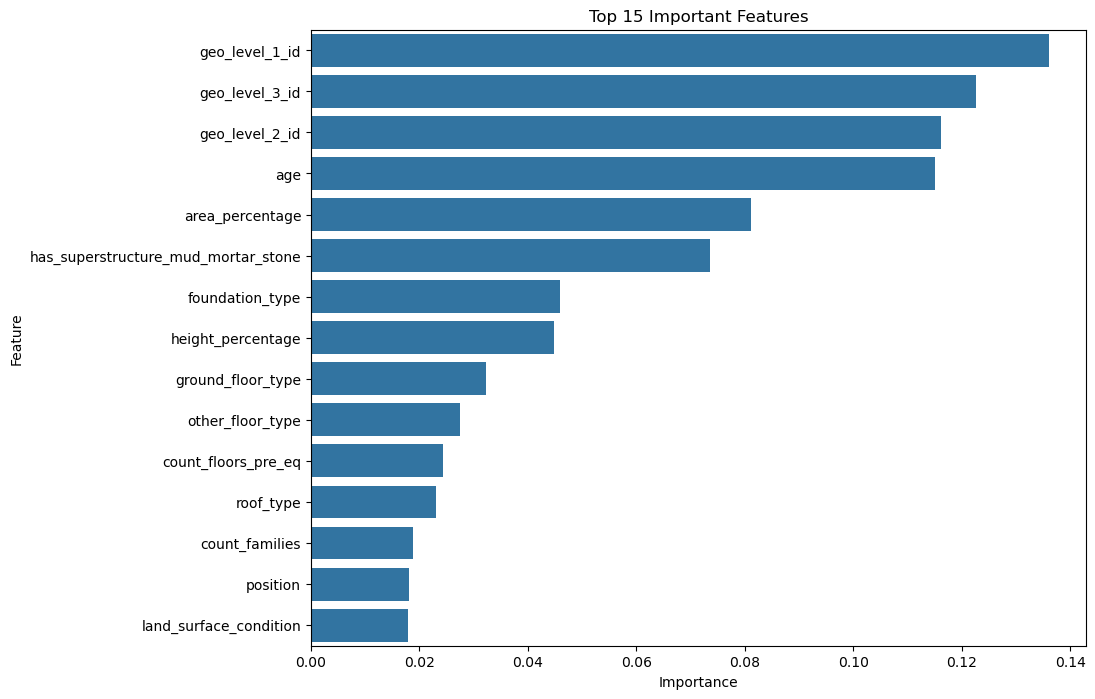

,Feature,Importance
0,geo_level_1_id,0.136096
2,geo_level_3_id,0.122619
1,geo_level_2_id,0.116217
4,age,0.115094
5,area_percentage,0.081205
15,has_superstructure_mud_mortar_stone,0.073588
8,foundation_type,0.046011
6,height_percentage,0.044763
10,ground_floor_type,0.032284
11,other_floor_type,0.027489


In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title('Top 15 Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

feature_importance.head(15)

### Observation

The feature importance analysis shows that **geographical variables** are the most influential predictors of earthquake damage. The top three features are:

* **geo_level_1_id (13.61%)**
* **geo_level_3_id (12.26%)**
* **geo_level_2_id (11.62%)**

Together, these geographical features contribute a substantial portion of the model’s predictive power, indicating that location plays a major role in determining damage severity.

Among the structural characteristics, **age (11.51%)** is one of the most important features, suggesting that older buildings are more vulnerable to earthquake damage. **area_percentage (8.12%)** and **has_superstructure_mud_mortar_stone (7.36%)** also have significant influence, highlighting the importance of building size and construction material.

Other relevant features include **foundation_type (4.60%)**, **height_percentage (4.48%)**, **ground_floor_type (3.23%)**, and **other_floor_type (2.75%)**, which indicates that foundation and floor construction characteristics contribute meaningfully to damage prediction.

Overall, the model suggests that earthquake damage is driven by a combination of **geographical location, building age, construction material, and structural characteristics**, with geographical factors having the strongest overall impact.


## Interpretation of Feature Importance

The feature importance results indicate that geographical location contributes the largest share of predictive information, while building age and construction characteristics provide additional explanatory power. This finding suggests that earthquake vulnerability is influenced not only by the structural condition of a building but also by the regional and local geographical context in which the building is located.


## Final Discussion

The complete machine learning workflow demonstrates that earthquake damage prediction is a **multi-factor classification problem**. The exploratory analysis showed that geographical location, building age, construction material, and structural characteristics all contribute to damage severity.

The model comparison revealed a clear progression in performance:

* Logistic Regression: **42.10%**
* Decision Tree: **64.68%**
* Random Forest: **70.54%**
* XGBoost: **69.23%**

The substantial improvement from Logistic Regression to Random Forest indicates that the relationship between building characteristics and earthquake damage is highly non-linear. Ensemble tree-based methods were able to capture complex feature interactions more effectively than linear models.

Feature-importance analysis further confirmed that **geographical variables are the strongest predictors**, followed by building age and construction-related features. This suggests that both environmental exposure and structural vulnerability jointly influence earthquake damage outcomes.

The final Random Forest model achieved approximately **70.54% accuracy** and **70.58% weighted F1-score**, providing a balanced and reliable prediction across all damage grades.


## Conclusion

This project successfully developed a machine learning system for predicting earthquake building damage grades using structural, geographical, and ownership-related features. Exploratory data analysis identified class imbalance, skewed numerical distributions, and important structural characteristics affecting earthquake damage severity.

The dataset was preprocessed by removing the identifier column, encoding categorical variables, and balancing the training data using SMOTE. Four classification algorithms—**Logistic Regression, Decision Tree, Random Forest, and XGBoost**—were trained and evaluated on the test dataset.

Among all models, the **Random Forest Classifier** achieved the best overall performance with approximately **70.54% accuracy** and **70.58% weighted F1-score**. Hyperparameter tuning confirmed that the selected Random Forest configuration was the best among the evaluated parameter combinations.

Feature-importance analysis revealed that **geographical location, building age, construction material, and structural characteristics** are the most influential factors in earthquake damage prediction. The study demonstrates that ensemble tree-based methods are effective for modeling complex non-linear relationships in earthquake damage assessment.

Overall, the developed model provides a reliable framework for supporting earthquake damage prediction and can assist disaster management authorities in identifying vulnerable buildings and prioritizing response activities.


## Real-World Impact

The developed earthquake damage prediction model can provide several practical benefits for disaster management and infrastructure planning:

* **Rapid Damage Assessment:** Helps estimate building damage severity immediately after an earthquake.
* **Prioritization of Rescue Operations:** Assists emergency responders in identifying areas with potentially severe damage.
* **Infrastructure Risk Assessment:** Supports government agencies in identifying vulnerable building categories for retrofitting and strengthening.
* **Resource Allocation:** Enables efficient distribution of relief materials, medical support, and reconstruction resources.
* **Urban Planning Support:** Provides insights for safer building regulations and disaster-resilient urban development.
* **Preparedness Improvement:** Helps authorities plan mitigation strategies in high-risk geographical regions.

By automating damage prediction, the model can reduce assessment time and support faster and more informed decision-making during earthquake emergencies.


## Limitations

Although the model achieved good predictive performance, several limitations should be considered:

* The model was trained on a historical dataset and may not generalize perfectly to all countries or earthquake conditions.
* Some categorical features were encoded numerically, which may not fully capture engineering or material-specific characteristics.
* Extreme outliers were retained because they appeared to represent real buildings; however, they may still influence model behavior.
* The dataset does not include important seismic variables such as earthquake magnitude, ground acceleration, soil type, and fault distance.
* The model predicts categorical damage grades rather than exact structural damage measurements.
* Temporal changes in building conditions were not available, so the model cannot account for deterioration over time.

These limitations indicate that the model should be used as a decision-support tool rather than a replacement for detailed engineering inspection.


## Future Scope

The project can be further improved through several future enhancements:

* Integrating additional seismic and environmental variables such as soil condition, earthquake intensity, and ground acceleration.
* Evaluating advanced boosting algorithms such as **LightGBM** and **CatBoost** for potentially higher predictive performance.
* Performing domain-specific feature engineering using structural engineering indicators.
* Applying explainable AI techniques such as **SHAP** to improve model interpretability and decision transparency.
* Developing a web or mobile application for real-time earthquake damage prediction.
* Incorporating geospatial visualization to display high-risk regions on interactive maps.
* Updating the model with new earthquake events to improve robustness and long-term generalization.
* Combining machine learning with remote-sensing or satellite imagery for automated large-scale damage assessment.

These enhancements can increase prediction accuracy, interpretability, and practical usability in real-world disaster management systems.


## Sample Prediction Using the Final Model

The final optimized Random Forest model is used to generate predictions for a few unseen test records to demonstrate how the model predicts earthquake damage grades.


In [41]:
sample_predictions = final_rf_model.predict(X_test.head(5))

prediction_results = pd.DataFrame({
    'Actual Damage Grade': y_test.head(5).values,
    'Predicted Damage Grade': sample_predictions
})

prediction_results

,Actual Damage Grade,Predicted Damage Grade
0,3,2
1,2,2
2,2,1
3,2,2
4,3,3


### Observation

The final Random Forest model was tested on a small set of unseen samples. Out of the five records, the model predicted three damage grades correctly and made two incorrect predictions.

| Actual Damage Grade | Predicted Damage Grade |
| ------------------- | ---------------------- |
| 3                   | 2                      |
| 2                   | 2                      |
| 2                   | 1                      |
| 2                   | 2                      |
| 3                   | 3                      |

The predictions show that the model is capable of identifying earthquake damage grades on unseen data, although some misclassifications still occur. The errors are mainly between neighboring damage categories, which is common in multi-class classification problems where the class boundaries overlap. This example demonstrates the practical usage of the trained model for real-world earthquake damage prediction.


## Project Completion

This project successfully developed and evaluated machine learning models for earthquake damage prediction using structural and geographical building information. The final Random Forest model was selected based on its superior predictive performance and balanced classification capability. The project demonstrates a complete end-to-end machine learning pipeline, including data understanding, exploratory analysis, preprocessing, class balancing, model development, evaluation, optimization, and interpretation.
